# Keypoint MoSeq Syllable Transition Analysis

This notebook loads `syllable_frames.csv` and visualizes:

- syllables over time
- frame-to-frame syllable transitions over time
- transition probability matrices
- transition counts in coarse time bins


In [1]:
from pathlib import Path

from IPython.display import HTML, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk")
sns.set_style("whitegrid")

## Paths

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Pose_Tracking":
    POSE_TRACKING_DIR = PROJECT_ROOT
else:
    POSE_TRACKING_DIR = PROJECT_ROOT / "Pose_Tracking"

project_dir = POSE_TRACKING_DIR / "keypoint_moseq_project_home_cage"
model_name = "2026_04_28-12_42_32"
syllable_frames_path = project_dir / model_name / "syllable_frames.csv"

syllable_frames_path

WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage/2026_04_28-12_42_32/syllable_frames.csv')

## Load Syllable Frames

In [3]:
df = pd.read_csv(syllable_frames_path)
df = df.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
df.head()

,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_agent,0,33,0.0,155.657282,307.141571,1.130912,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
1,n5_agent,1,33,0.1,154.826796,307.131103,0.075902,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
2,n5_agent,2,33,0.2,155.375966,307.940911,2.704693,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
3,n5_agent,3,33,0.3,155.517562,308.555278,-1.225559,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
4,n5_agent,4,33,0.4,154.527486,308.025377,-0.452464,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN


## Helper Functions

In [4]:
def subset_syllable_frames(df, recording_name=None, subject_name=None, track_name=None):
    out = df.copy()
    if recording_name is not None:
        out = out[out["recording_name"] == recording_name]
    if subject_name is not None:
        out = out[out["subject_name"] == subject_name]
    if track_name is not None:
        out = out[out["track_name"] == track_name]
    return out.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)


def extract_syllable_transitions(df):
    df = df.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
    parts = []

    for recording_name, rec in df.groupby("recording_name", sort=False):
        rec = rec.sort_values("frame_index").reset_index(drop=True)
        if len(rec) < 2:
            continue

        prev = rec.iloc[:-1].reset_index(drop=True)
        curr = rec.iloc[1:].reset_index(drop=True)
        consecutive = (curr["frame_index"].to_numpy() - prev["frame_index"].to_numpy()) == 1
        if not consecutive.any():
            continue

        transitions = pd.DataFrame({
            "recording_name": recording_name,
            "subject_name": prev.loc[consecutive, "subject_name"].to_numpy() if "subject_name" in prev.columns else None,
            "track_name": prev.loc[consecutive, "track_name"].to_numpy() if "track_name" in prev.columns else None,
            "from_frame": prev.loc[consecutive, "frame_index"].to_numpy(),
            "to_frame": curr.loc[consecutive, "frame_index"].to_numpy(),
            "time_s": curr.loc[consecutive, "time_s"].to_numpy(),
            "from_syllable": prev.loc[consecutive, "syllable"].to_numpy(),
            "to_syllable": curr.loc[consecutive, "syllable"].to_numpy(),
        })
        transitions["transition_label"] = (
            transitions["from_syllable"].astype(str) + "->" + transitions["to_syllable"].astype(str)
        )
        transitions["changed"] = transitions["from_syllable"] != transitions["to_syllable"]
        parts.append(transitions)

    if not parts:
        return pd.DataFrame(columns=[
            "recording_name", "subject_name", "track_name", "from_frame", "to_frame",
            "time_s", "from_syllable", "to_syllable", "transition_label", "changed"
        ])

    return pd.concat(parts, ignore_index=True)


def make_transition_matrix(transitions_df, normalize=True):
    matrix = pd.crosstab(transitions_df["from_syllable"], transitions_df["to_syllable"])
    matrix = matrix.sort_index().sort_index(axis=1)
    if normalize:
        matrix = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return matrix


def summarize_transition_windows(transitions_df, bin_s=30.0):
    out = transitions_df.copy()
    out["time_bin_start_s"] = np.floor(out["time_s"] / bin_s) * bin_s
    return (
        out.groupby(["time_bin_start_s", "transition_label"])
        .size()
        .reset_index(name="n_transitions")
        .sort_values(["time_bin_start_s", "n_transitions"], ascending=[True, False])
    )


def plot_syllable_timeline(df, title="Syllables Over Time", ax=None, s=8):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 4))
    ordered = df.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
    ax.scatter(
        ordered["time_s"], ordered["syllable"],
        c=ordered["syllable"], cmap="tab20", s=s, linewidths=0, alpha=0.9
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Syllable")
    ax.set_title(title)
    return ax


def plot_transition_timeline(transitions_df, top_n=15, changed_only=True, title="Syllable Transitions Over Time", ax=None, s=10):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 6))

    data = transitions_df.copy()
    if changed_only:
        data = data[data["changed"]]

    top_labels = data["transition_label"].value_counts().head(top_n).index.tolist()
    data = data[data["transition_label"].isin(top_labels)].copy()
    if data.empty:
        raise ValueError("No transitions available to plot after filtering.")

    label_order = list(reversed(top_labels))
    y_map = {label: idx for idx, label in enumerate(label_order)}
    ax.scatter(
        data["time_s"], data["transition_label"].map(y_map),
        c=data["from_syllable"], cmap="tab20", s=s, linewidths=0, alpha=0.85
    )
    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(label_order)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Transition")
    ax.set_title(title)
    return ax


def plot_transition_matrix(transitions_df, normalize=True, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 7))
    matrix = make_transition_matrix(transitions_df, normalize=normalize)
    sns.heatmap(matrix, cmap="mako", ax=ax)
    ax.set_xlabel("To syllable")
    ax.set_ylabel("From syllable")
    if title is None:
        title = "Transition Probability Matrix" if normalize else "Transition Count Matrix"
    ax.set_title(title)
    return ax

## Choose a Recording or Pooling Strategy

Examples:

- `recording_name = "n5_subject"`
- `subject_name = "n5"`
- `track_name = "subject"`
- leave all as `None` to use the full dataset

In [5]:
recording_name = "n5_subject"
subject_name = None
track_name = None

df_sel = subset_syllable_frames(
    df,
    recording_name=recording_name,
    subject_name=subject_name,
    track_name=track_name,
)
df_sel.head()

,recording_name,frame_index,syllable,time_s,centroid_x,centroid_y,heading,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_subject,0,33,0.0,149.242960,308.021917,-2.874991,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
1,n5_subject,1,33,0.1,148.684429,307.693357,-2.901321,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
2,n5_subject,2,33,0.2,147.290390,308.486806,0.912420,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
3,n5_subject,3,33,0.3,147.517330,307.442960,-2.163721,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN
4,n5_subject,4,33,0.4,146.841850,307.623480,-0.748182,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,17728,10.0,NaN,NaN,NaN


## Extract Transitions

In [6]:
transitions = extract_syllable_transitions(df_sel)
transitions.head()

,recording_name,subject_name,track_name,from_frame,to_frame,time_s,from_syllable,to_syllable,transition_label,changed
0,n5_subject,n5,subject,0,1,0.1,33,33,33->33,False
1,n5_subject,n5,subject,1,2,0.2,33,33,33->33,False
2,n5_subject,n5,subject,2,3,0.3,33,33,33->33,False
3,n5_subject,n5,subject,3,4,0.4,33,33,33->33,False
4,n5_subject,n5,subject,4,5,0.5,33,33,33->33,False


## Plot Syllables and Transitions Over Time

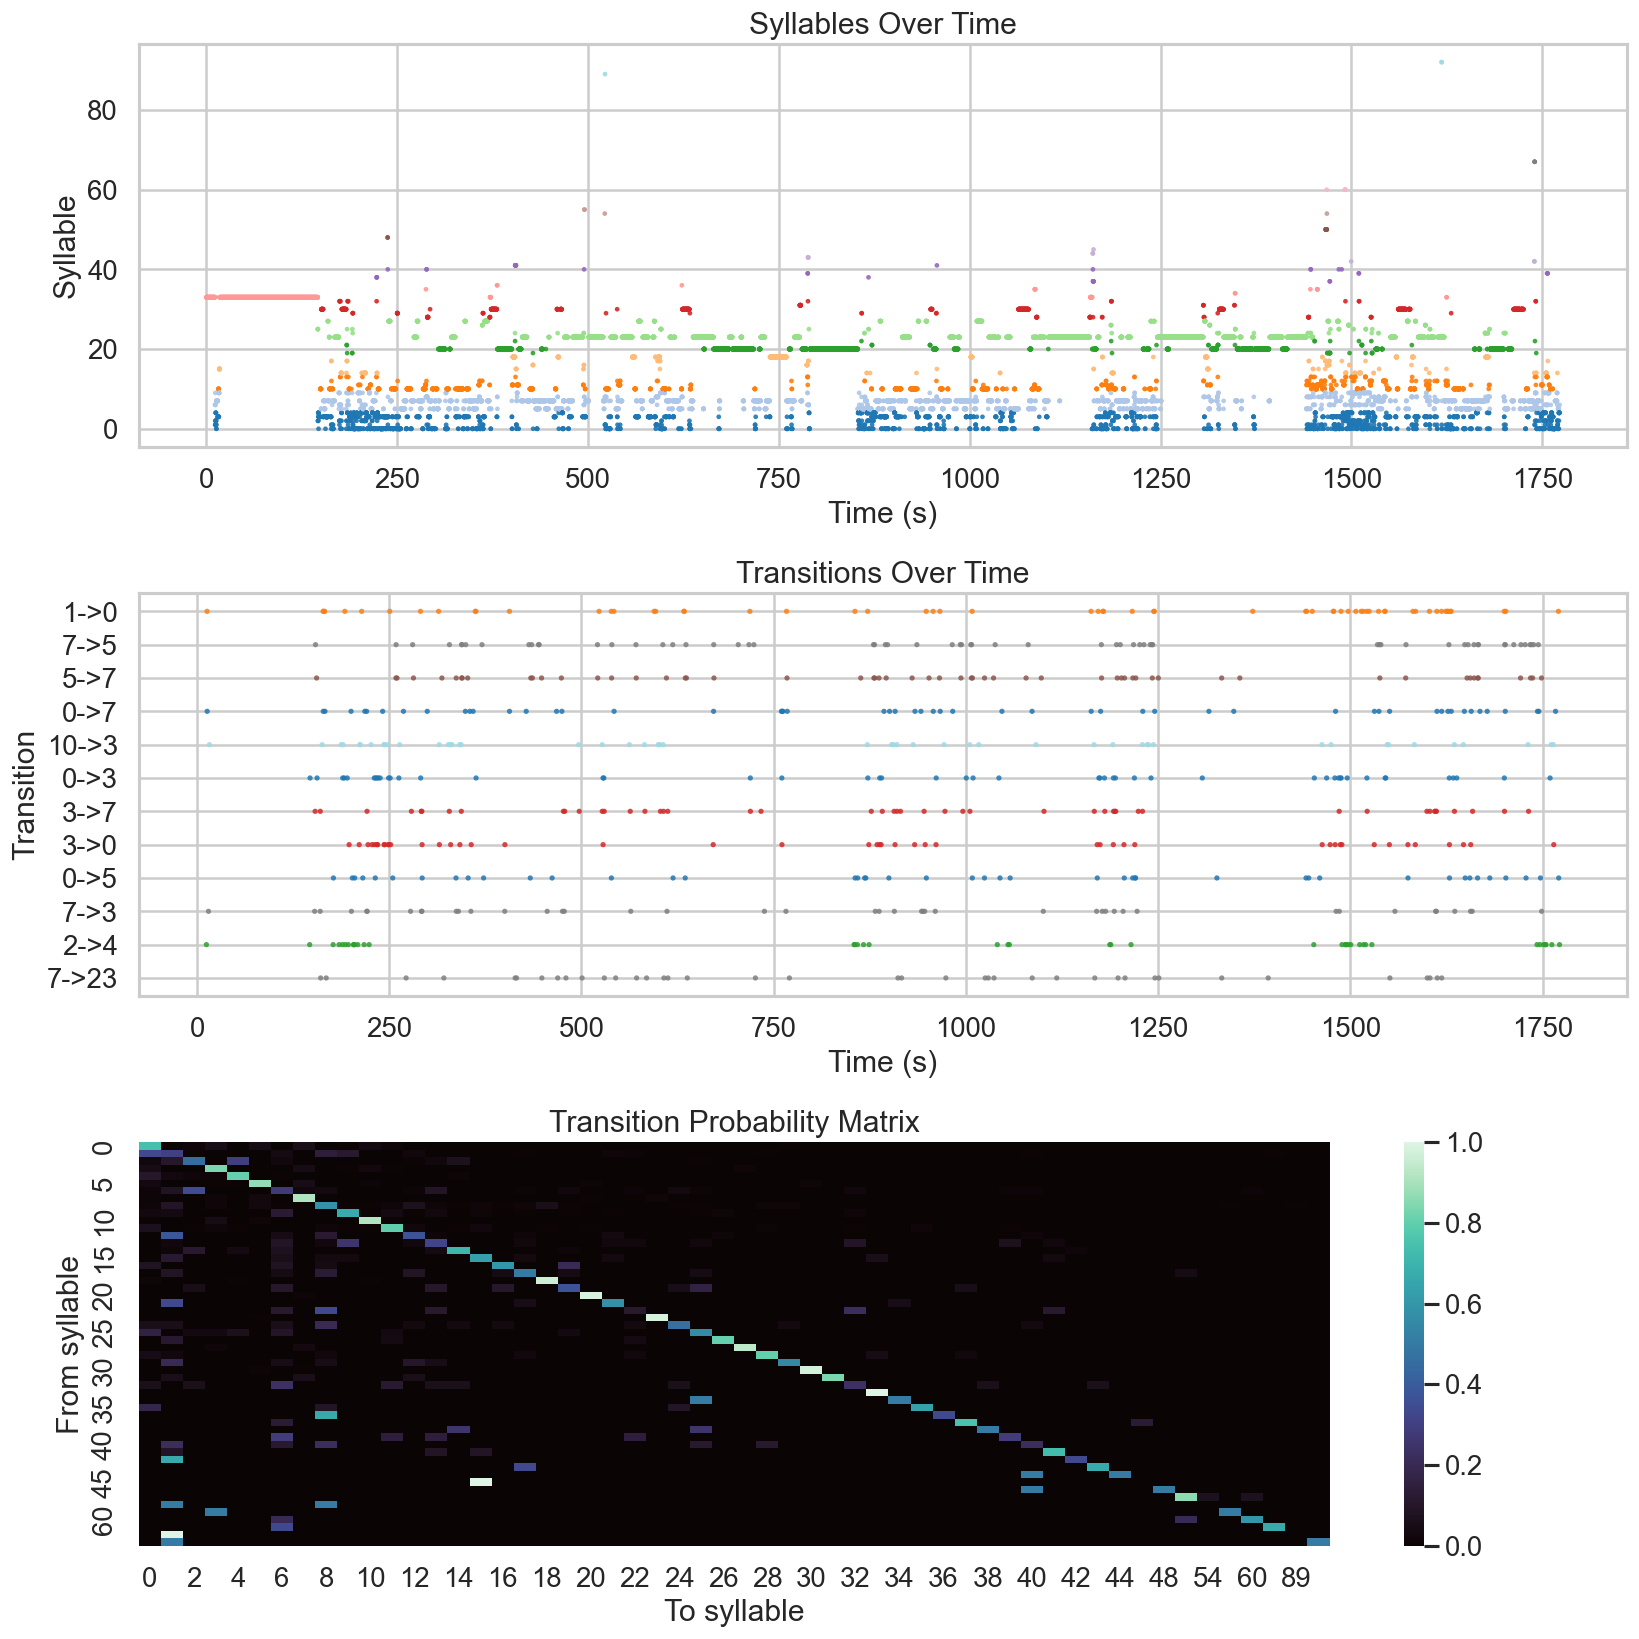

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
plot_syllable_timeline(df_sel, title="Syllables Over Time", ax=axes[0])
plot_transition_timeline(transitions, top_n=12, title="Transitions Over Time", ax=axes[1])
plot_transition_matrix(transitions, normalize=True, title="Transition Probability Matrix", ax=axes[2])
plt.tight_layout()

## Transition Counts in Coarse Time Bins

In [8]:
window_summary = summarize_transition_windows(transitions, bin_s=30.0)
window_summary.head(20)

,time_bin_start_s,transition_label,n_transitions
15,0.0,33->33,236
23,0.0,7->7,16
13,0.0,3->3,8
7,0.0,15->15,6
5,0.0,10->10,4
10,0.0,2->2,3
18,0.0,4->4,3
26,0.0,9->9,3
3,0.0,1->1,2
0,0.0,0->0,1


## Optional: Plot the Most Common Transitions by Time Bin

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\albe

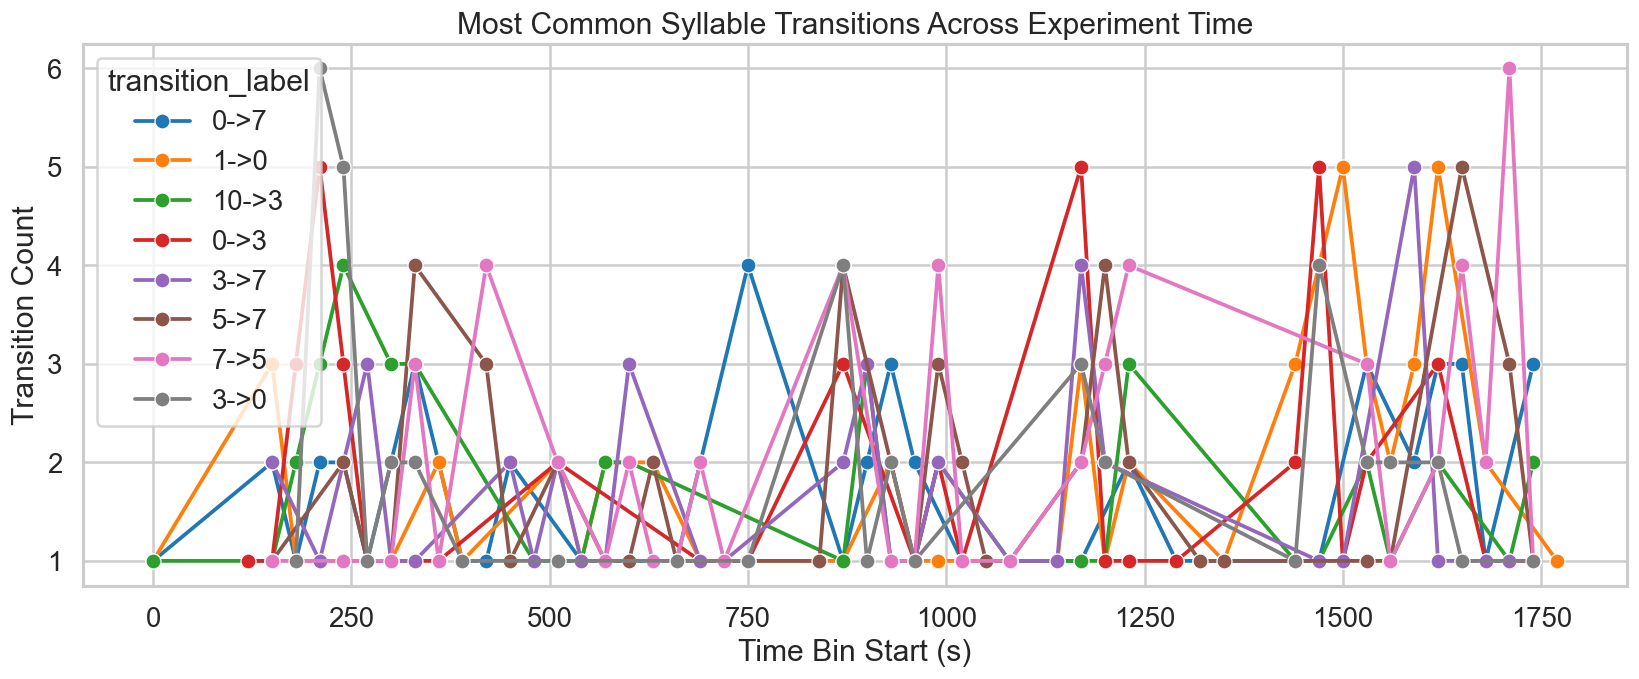

In [9]:
top_labels = transitions.loc[transitions["changed"], "transition_label"].value_counts().head(8).index.tolist()
plot_df = window_summary[window_summary["transition_label"].isin(top_labels)].copy()

plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_df, x="time_bin_start_s", y="n_transitions", hue="transition_label", marker="o")
plt.xlabel("Time Bin Start (s)")
plt.ylabel("Transition Count")
plt.title("Most Common Syllable Transitions Across Experiment Time")
plt.tight_layout()

## Syllable GIF Gallery

In [11]:
trajectory_dir = project_dir / model_name / "trajectory_plots_custom"
if not trajectory_dir.exists():
    trajectory_dir = project_dir / model_name / "trajectory_plots"

gif_paths = sorted(
    trajectory_dir.glob("Syllable*.gif"),
    key=lambda path: int(path.stem.replace("Syllable", "")),
)

cards = []
for gif_path in gif_paths:
    syllable_id = int(gif_path.stem.replace("Syllable", ""))
    cards.append(
        f"""
        <div style='display:inline-block; width:240px; margin:10px; text-align:center; vertical-align:top;'>
            <div style='font-weight:600; margin-bottom:6px;'>Syllable {syllable_id}</div>
            <img src='{gif_path.as_posix()}' style='max-width:220px; border:1px solid #ccc;' />
        </div>
        """
    )

# display(HTML("<div style='display:flex; flex-wrap:wrap; align-items:flex-start;">" + "".join(cards) + "</div>"))
print(f"Displayed {len(gif_paths)} syllable GIFs from {trajectory_dir}")

Displayed 30 syllable GIFs from c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_04_28-12_42_32\trajectory_plots_custom
